In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
benchmark_df = pd.read_csv(r'./uniprot_dataset/benchmark_df.csv')
reproduced_df = pd.read_csv(r'./uniprot_dataset/reproduced_df.csv')

In [3]:
print(len(benchmark_df))
print(len(reproduced_df))

72731
74258


In [4]:
# Normalize column names for direct comparison
benchmark_pairs = benchmark_df[['uniprot_id', 'aa_change']].rename(columns={'uniprot_id': 'seq_id', 'aa_change': 'mut_name'})
reproduced_pairs = reproduced_df[['seq_id', 'mut_name']]

# Find missing pairs
missing_entries = benchmark_pairs.merge(reproduced_pairs, on=['seq_id', 'mut_name'], how='left', indicator=True)
missing_entries = missing_entries[missing_entries['_merge'] == 'left_only'].drop(columns=['_merge'])

print(f"Missing (seq_id, mut_name) pairs in reproduced_df: {len(missing_entries)}")
print(missing_entries.head())

unique_missing_seq_ids = missing_entries[['seq_id']].drop_duplicates()
print(f"Unique missing seq_id values in reproduced_df: {len(unique_missing_seq_ids)}")
print(unique_missing_seq_ids['seq_id'].tolist())


Missing (seq_id, mut_name) pairs in reproduced_df: 429
     seq_id mut_name
913  O00255    C426Y
914  O00255    S432R
915  O00255    W441C
916  O00255    D423Y
917  O00255    D423H
Unique missing seq_id values in reproduced_df: 111
['O00255', 'O75319', 'O75747', 'O76011', 'O76036', 'O95755', 'P01019', 'P02708', 'P06731', 'P07686', 'P0C6A0', 'P11182', 'P18887', 'P20929', 'P21675', 'P23109', 'P29973', 'P33261', 'P43026', 'P49842', 'P51587', 'P54296', 'P57071', 'P59826', 'P59901', 'P60370', 'P60371', 'Q03518', 'Q08AF8', 'Q0D2K0', 'Q14002', 'Q14241', 'Q2M2W7', 'Q3KPI0', 'Q3LFD5', 'Q3MIN7', 'Q5T890', 'Q5TI25', 'Q5VWP3', 'Q6GMV1', 'Q6GTX8', 'Q6IFG1', 'Q6NSX1', 'Q6P4F2', 'Q6P587', 'Q6RUI8', 'Q6SJ96', 'Q6URK8', 'Q6ZRC1', 'Q6ZVW7', 'Q7RTR8', 'Q7Z4U5', 'Q8IV35', 'Q8IXP5', 'Q8N5Z5', 'Q8N8F6', 'Q8N957', 'Q8NBV8', 'Q8NFD5', 'Q8NFV4', 'Q8NGC3', 'Q8NGH7', 'Q8NGJ2', 'Q8NGR6', 'Q8NGR9', 'Q8NGV7', 'Q8NH41', 'Q8NHH1', 'Q8TC94', 'Q8TD46', 'Q8TDS5', 'Q8TE02', 'Q8WU43', 'Q8WV35', 'Q92581', 'Q96DA0', 'Q96FT7

In [8]:
missing_in_benchmark = reproduced_pairs.merge(benchmark_pairs, on=['seq_id', 'mut_name'], how='left', indicator=True)
missing_in_benchmark = missing_in_benchmark[missing_in_benchmark['_merge'] == 'left_only'].drop(columns=['_merge'])

print(f"Missing (seq_id, mut_name) pairs in benchmark_df: {len(missing_in_benchmark)}")
print(missing_in_benchmark.head())

# Find unique seq_id values missing in benchmark_df
unique_missing_seq_ids_benchmark = missing_in_benchmark[['seq_id']].drop_duplicates()
print(f"Unique missing seq_id values in benchmark_df: {len(unique_missing_seq_ids_benchmark)}")
print(unique_missing_seq_ids_benchmark['seq_id'].tolist())

Missing (seq_id, mut_name) pairs in benchmark_df: 1956
     seq_id mut_name
12   A0JNW5    S797L
61   A1L188      M1V
63   A1L390    R958H
126  A2RRH5    L133P
177  A2RU37     V84I
Unique missing seq_id values in benchmark_df: 890
['A0JNW5', 'A1L188', 'A1L390', 'A2RRH5', 'A2RU37', 'A2RUQ5', 'A4D126', 'A6NC78', 'A6NER0', 'A6NI61', 'A6NJ64', 'A6NNF4', 'A6NNZ2', 'A6PVC2', 'A8K8P3', 'A8MXY4', 'A8MZ25', 'B0YJ81', 'B1AH88', 'B1APH4', 'C9JR72', 'D6RF30', 'E9PB15', 'O00170', 'O00255', 'O00468', 'O14490', 'O14521', 'O14525', 'O14802', 'O14836', 'O14936', 'O14958', 'O14965', 'O15061', 'O15078', 'O15118', 'O15273', 'O15303', 'O15305', 'O15360', 'O15520', 'O15537', 'O43272', 'O43291', 'O43323', 'O43426', 'O43511', 'O43526', 'O43602', 'O43819', 'O43822', 'O43826', 'O43914', 'O43918', 'O43929', 'O43933', 'O60229', 'O60260', 'O60494', 'O60645', 'O60683', 'O60716', 'O60733', 'O60880', 'O75015', 'O75022', 'O75023', 'O75204', 'O75251', 'O75352', 'O75360', 'O75431', 'O75478', 'O75489', 'O75596', 'O75648'

In [5]:
benchmark_score = benchmark_df['ESM1b_score'].tolist()
reproduced_score = reproduced_df['esm_score'].tolist()

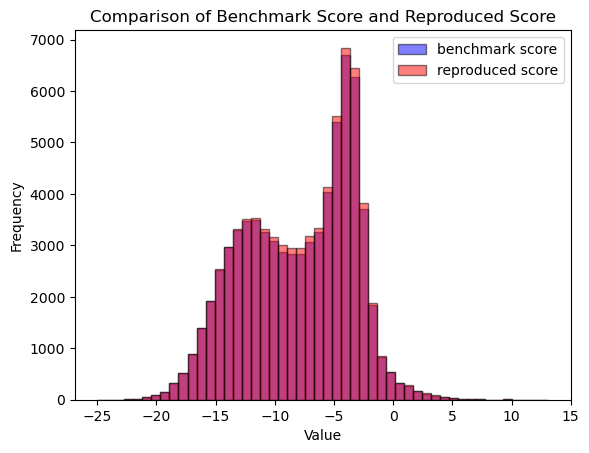

In [6]:
plt.hist(benchmark_score, bins=50, alpha=0.5, label='benchmark score', color='blue', edgecolor='black')
plt.hist(reproduced_score, bins=50, alpha=0.5, label='reproduced score', color='red', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Comparison of Benchmark Score and Reproduced Score')

plt.legend()
plt.savefig(r'./uniprot_dataset/benchmark_reproduce_comparison.jpg')

plt.show()

In [7]:
differences = np.array(benchmark_score) - np.array(reproduced_score)

plt.hist(differences, bins=50, color='purple', edgecolor='black', alpha=0.7)

plt.axvline(0, color='black', linestyle='dashed', linewidth=2)
plt.xlabel('Difference (Benchmark - Reproduced)')
plt.ylabel('Frequency')
plt.title('Histogram of Differences')

plt.savefig(r'./uniprot_dataset/difference_histogram.jpg')
plt.show()

ValueError: operands could not be broadcast together with shapes (72731,) (74258,) 